<a href="https://colab.research.google.com/github/MontanezQuirozRolo/-MachineLearning_West-Airlines/blob/main/Machine_Learning_West_Airlines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Caso aplicativo Machine Learning: West Airlines

West Airlines es una empresa de transporte aéreo que recientemente realizó una alianza con
una empresa de telecomunicaciones para la venta de servicios de comunicación. La data contiene la información de clientes a los que se le ofreció el servicio y
los que respondieron de forma favorable. Se busca elaborar un modelo predictivo que cubra las necesidades de la aerolínea, para potenciar la
marca y realizar una venta más efectiva del servicio.


### Variables usadas
###### Topflight: Indica si el cliente tiene estatus élite en la aerolínea. 1 = Sí (cliente frecuente premium) 0 = No
###### Balance: Cantidad total de millas acumuladas que el cliente  puede usar para canjear viajes o beneficios.
###### Qual_miles: Millas que cuentan específicamente para subir o mantener el nivel élite (no todas las millas aplican para esto).
###### cc1_miles?: Indica si el cliente ganó millas usando una tarjeta de crédito de la aerolínea en el último año. 1 = Sí, 0 = No
###### cc2_miles?: Indica si el cliente ganó millas usando una tarjeta de crédito tipo “Rewards” en el último año. 1 = Sí, 0 = No
###### cc3_miles?: Indica si el cliente ganó millas usando una tarjeta de crédito para negocios en el último año. 1 = Sí, 0 = No
###### Bonus_miles: Cantidad de millas que el cliente ganó por actividades que no son vuelos (por ejemplo: compras, promociones, aliados, etc.) en el último año.
###### Bonus_trans: Número de veces que el cliente realizó actividades que le dieron millas extra (sin contar vuelos).
###### Flight_miles_12mo: Total de millas voladas por el cliente en los últimos 12 meses.
###### Flight_trans_12: Número de vuelos que realizó el cliente en los últimos 12 meses.
###### Online_12: Cantidad de compras o transacciones que el cliente hizo por internet en el último año.
###### Email: Indica si se tiene registrado el correo electrónico del cliente. 1 = Sí, 0 = No
###### Club_member: Indica si el cliente paga una membresía especial de la aerolínea (club exclusivo). 1 = Sí, 0 = No
###### Any_cc_miles_12mo: Indica si el cliente ganó millas usando cualquier tipo de tarjeta de crédito en el último año (sin importar cuál). 1 = Sí, 0 = No
###### Phone_sale: Indica si el cliente compró un servicio como resultado de una campaña telefónica o mailing.1 = Compró 0 = No compró

## Importar librerías

In [ ]:
# Importación de librerías para manipulación de datos y visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías de Machine Learning (Scikit-Learn)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings('ignore')
print("Librerías importadas correctamente.")
from imblearn.over_sampling import SMOTE


Librerías importadas correctamente.


## Carga y limpieza de datos

In [ ]:
df = pd.read_csv('EastWestAirlinesNN.csv')

In [ ]:
display(df.head())

,ID#,Topflight,Balance,Qual_miles,cc1_miles?,cc2_miles?,cc3_miles?,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Online_12,Email,Club_member,Any_cc_miles_12mo,Phone_sale
0,1.0,0.0,28143.0,0.0,0.0,1.0,0.0,174.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,2.0,0.0,19244.0,0.0,0.0,0.0,0.0,215.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,0.0,41354.0,0.0,1.0,0.0,0.0,4123.0,4.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,4.0,0.0,14776.0,0.0,0.0,0.0,0.0,500.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,5.0,1.0,97752.0,0.0,1.0,0.0,0.0,43300.0,26.0,2077.0,4.0,0.0,1.0,0.0,1.0,0.0


In [ ]:
if 'ID#' in df.columns:
    df = df.drop('ID#', axis=1)

In [ ]:
df.dtypes

,0
Topflight,float64
Balance,float64
Qual_miles,float64
cc1_miles?,float64
cc2_miles?,float64
cc3_miles?,float64
Bonus_miles,float64
Bonus_trans,float64
Flight_miles_12mo,float64
Flight_trans_12,float64


In [ ]:
df.shape

(4987, 15)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4987 entries, 0 to 4986
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Topflight          4985 non-null   float64
 1   Balance            4985 non-null   float64
 2   Qual_miles         4985 non-null   float64
 3   cc1_miles?         4985 non-null   float64
 4   cc2_miles?         4985 non-null   float64
 5   cc3_miles?         4985 non-null   float64
 6   Bonus_miles        4986 non-null   float64
 7   Bonus_trans        4986 non-null   float64
 8   Flight_miles_12mo  4985 non-null   float64
 9   Flight_trans_12    4985 non-null   float64
 10  Online_12          4985 non-null   float64
 11  Email              4985 non-null   float64
 12  Club_member        4985 non-null   float64
 13  Any_cc_miles_12mo  4985 non-null   float64
 14  Phone_sale         4985 non-null   float64
dtypes: float64(15)
memory usage: 584.5 KB


In [ ]:
# Verificar valores nulos
print("\nValores nulos por columna:")
print(df.isnull().sum())


Valores nulos por columna:
Topflight            2
Balance              2
Qual_miles           2
cc1_miles?           2
cc2_miles?           2
cc3_miles?           2
Bonus_miles          1
Bonus_trans          1
Flight_miles_12mo    2
Flight_trans_12      2
Online_12            2
Email                2
Club_member          2
Any_cc_miles_12mo    2
Phone_sale           2
dtype: int64


In [ ]:
df[df.isnull().any(axis=1)]

,Topflight,Balance,Qual_miles,cc1_miles?,cc2_miles?,cc3_miles?,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Online_12,Email,Club_member,Any_cc_miles_12mo,Phone_sale
4985,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4986,NaN,NaN,NaN,NaN,NaN,NaN,4985.0,4985.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
display(df.tail())

,Topflight,Balance,Qual_miles,cc1_miles?,cc2_miles?,cc3_miles?,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Online_12,Email,Club_member,Any_cc_miles_12mo,Phone_sale
4982,0.0,10013.0,2436.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4983,0.0,4832.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4984,0.0,500.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4985,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4986,NaN,NaN,NaN,NaN,NaN,NaN,4985.0,4985.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Se ha encontrado que las dos nulos que se tiene en todas las variables se producen en las dos ultimas columnas, las mismas que no tienen nulos para las variables Bonus_miles y Bonus_Trans, el monto es el mismo 4985, por lo que se puede llegar a deducir que esto es un error de bases asi que se procedera a eliminar ambas columnas la 4985 y la 4986

In [ ]:
df = df.drop([4985, 4986])

In [ ]:
# Verificar valores nulos
print("\nValores nulos por columna:")
print(df.isnull().sum())


Valores nulos por columna:
Topflight            0
Balance              0
Qual_miles           0
cc1_miles?           0
cc2_miles?           0
cc3_miles?           0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Online_12            0
Email                0
Club_member          0
Any_cc_miles_12mo    0
Phone_sale           0
dtype: int64


## EDA

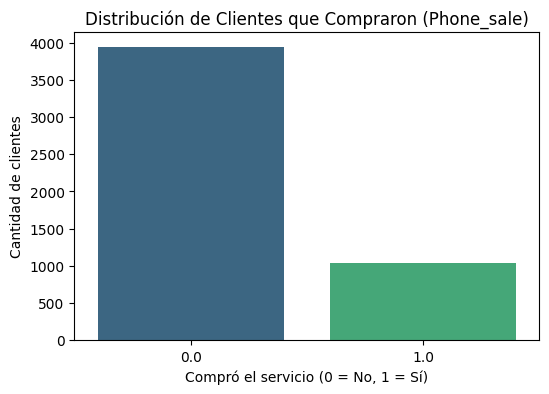

In [ ]:
# Ver la distribución de la variable objetivo (Venta: 1 = Sí, 0 = No)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Phone_sale', palette='viridis')
plt.title('Distribución de Clientes que Compraron (Phone_sale)')
plt.xlabel('Compró el servicio (0 = No, 1 = Sí)')
plt.ylabel('Cantidad de clientes')
plt.show()

#### **Hallazgos del grafico**
* Aproximadamente 3900–4000 clientes no realizaron la compra.
* Solo alrededor de 1000 clientes sí compraron.
*

In [ ]:
# Ver el porcentaje de conversión
conversion = df['Phone_sale'].value_counts(normalize=True) * 100
print(f"\nPorcentaje de clientes que compraron: {conversion[1]:.2f}%")
print(f"Porcentaje de clientes que NO compraron: {conversion[0]:.2f}%")


Porcentaje de clientes que compraron: 20.90%
Porcentaje de clientes que NO compraron: 79.10%


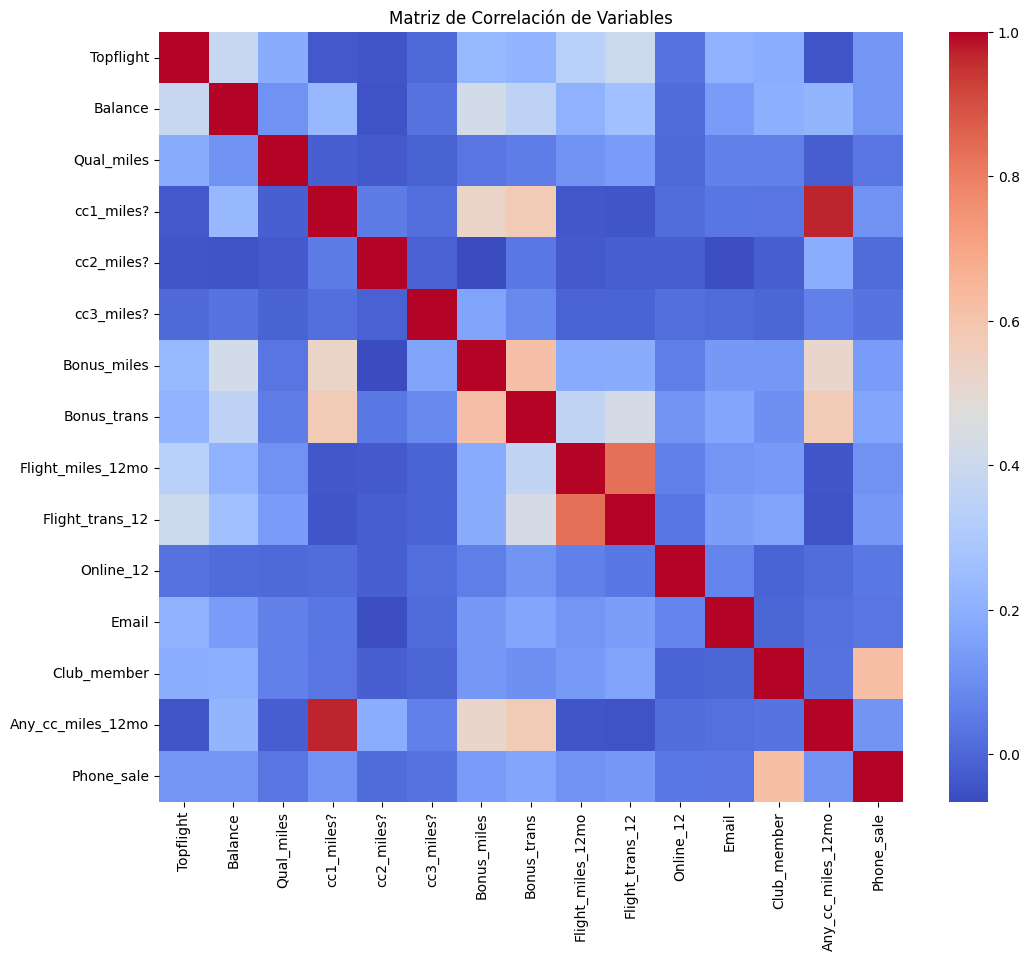

In [ ]:
# Matriz de correlación para ver qué variables se relacionan más con Phone_sale
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables')
plt.show()

#### **Hallazgos de la matriz de correlación**
1. Comportamiento de vuelo
   * Flight_miles_12mo ↔ Flight_trans_12 → Muy correlacionado
   * Tiene sentido: más vuelos → más millas
   * Estas variables son redundantes parcialmente
2. Actividad de bonos
   * Bonus_miles ↔ Bonus_trans → Alta correlación
   * Más transacciones → más millas ganadas fuera de vuelos
   * Representan engagement con promociones
3. Tarjetas de crédito  
   * cc1_miles ↔ Any_cc_miles_12mo → Muy alta
   * También cierta relación con Bonus_miles / Bonus_trans
   * Quien usa tarjeta → genera millas extra
   * Cliente más valioso / más activo
4. Nivel élite
   * Topflight Correlación moderada con:
      * Balance
      * Qual_miles
      * Actividad de vuelo
   * No es perfectamente correlacionado → hay reglas de negocio detrás
5. Variables con poca relación
   * Las variables: Email y Online_12 No influyen mucho en otras variables

#### **Conclusion**
* No hay multicolinealidad extrema general Solo en:
  * Flight variables
  * Bonus variables
  * Credit card variables


In [ ]:
# 1. Resumen estadístico (Media, Mediana, Desviación, Mínimo y Máximo)
print("\n--- Resumen Estadístico de Variables Numéricas ---")
# La mediana es el percentil 50%. Si la media está muy lejos del 50%, hay asimetría.
display(df.describe())


--- Resumen Estadístico de Variables Numéricas ---


,Topflight,Balance,Qual_miles,cc1_miles?,cc2_miles?,cc3_miles?,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Online_12,Email,Club_member,Any_cc_miles_12mo,Phone_sale
count,4985.000000,4.985000e+03,4985.000000,4985.000000,4985.000000,4985.000000,4985.000000,4985.000000,4985.000000,4985.000000,4985.000000,4985.000000,4985.000000,4985.000000,4985.000000
mean,0.167904,6.382099e+04,134.569107,0.519559,0.041525,0.005015,15579.973721,10.663791,426.472618,1.238716,0.054965,0.648746,0.091675,0.536008,0.209027
std,0.373818,9.360653e+04,731.679338,0.499667,0.199520,0.070646,22883.585808,9.505390,1428.041859,3.610721,0.506170,0.477410,0.288596,0.498752,0.406655
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.419200e+04,0.000000,0.000000,0.000000,0.000000,1000.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,3.469400e+04,0.000000,1.000000,0.000000,0.000000,5900.000000,10.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
75%,0.000000,7.796500e+04,0.000000,1.000000,0.000000,0.000000,21426.000000,16.000000,200.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000
max,1.000000,1.704838e+06,11148.000000,1.000000,1.000000,1.000000,263685.000000,88.000000,30817.000000,53.000000,11.000000,1.000000,1.000000,1.000000,1.000000


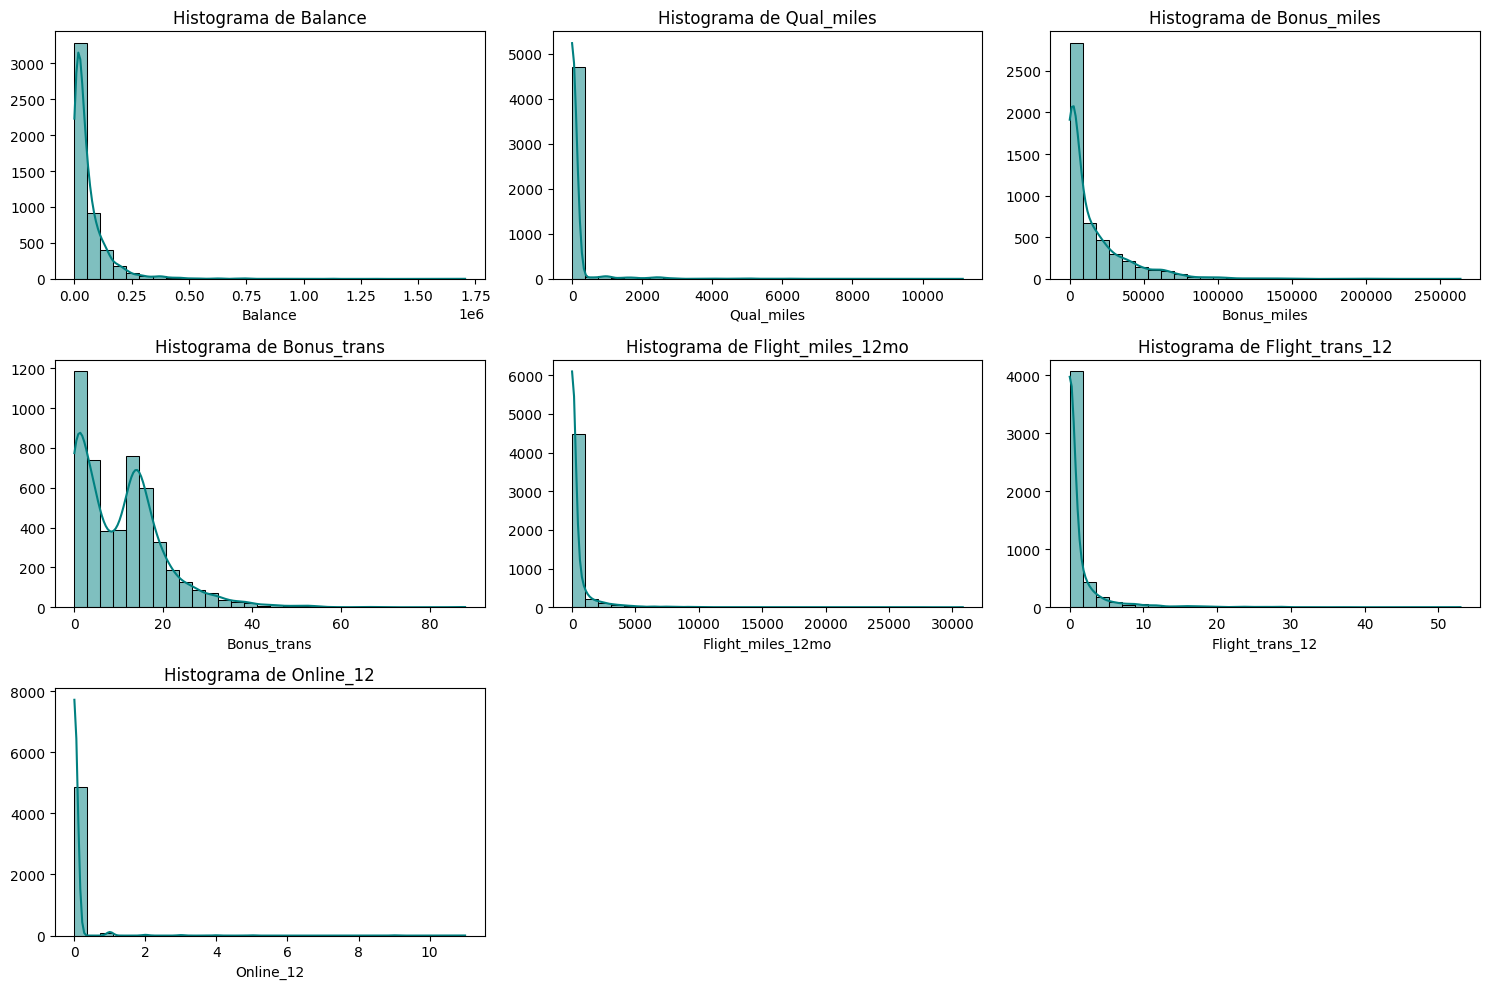

In [ ]:

# Lista de columnas numéricas continuas para graficar
num_cols = ['Balance', 'Qual_miles', 'Bonus_miles', 'Bonus_trans',
            'Flight_miles_12mo', 'Flight_trans_12', 'Online_12']

# 2. Histogramas para ver la distribución (Campana de Gauss vs Asimetría)
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    # kde=True dibuja la línea de tendencia de la distribución
    sns.histplot(df[col], kde=True, bins=30, color='teal')
    plt.title(f'Histograma de {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

#### **Hallazgos del grafico de Histogramas**
1. Variables de vuelo (Flight_miles_12mo, Flight_trans_12)
   * Mucha concentración en valores cercanos a 0
   * Cola larga hacia la derecha
2. Variables de bonos (Bonus_miles, Bonus_trans)
   * Distribución similar: sesgada a la derecha
   * Algunos valores extremadamente altos
3. Balance (millas acumuladas)
   * Muy sesgada
   * Valores extremos bastante grandes  
4. Qual_miles
   * Misma lógica que balance, pero más controlado
5. Online_12
   * Ultra concentrado en 0–1
   * Muy pocos valores altos
6. Bonus_trans
   * Forma un poco más “distribuida”, pero igual sesgada

**Interpretacion**
* Casi todas las variables están fuertemente sesgadas a la derecha (right-skewed) La mayoría de clientes tiene valores bajos

* Outliers fuertes
   * Variables con outliers claros: Balance, Bonus_miles, Flight_miles_12mo

* Escalamiento
   * Las variables están en rangos muy distintos: Online_12, Balance
   

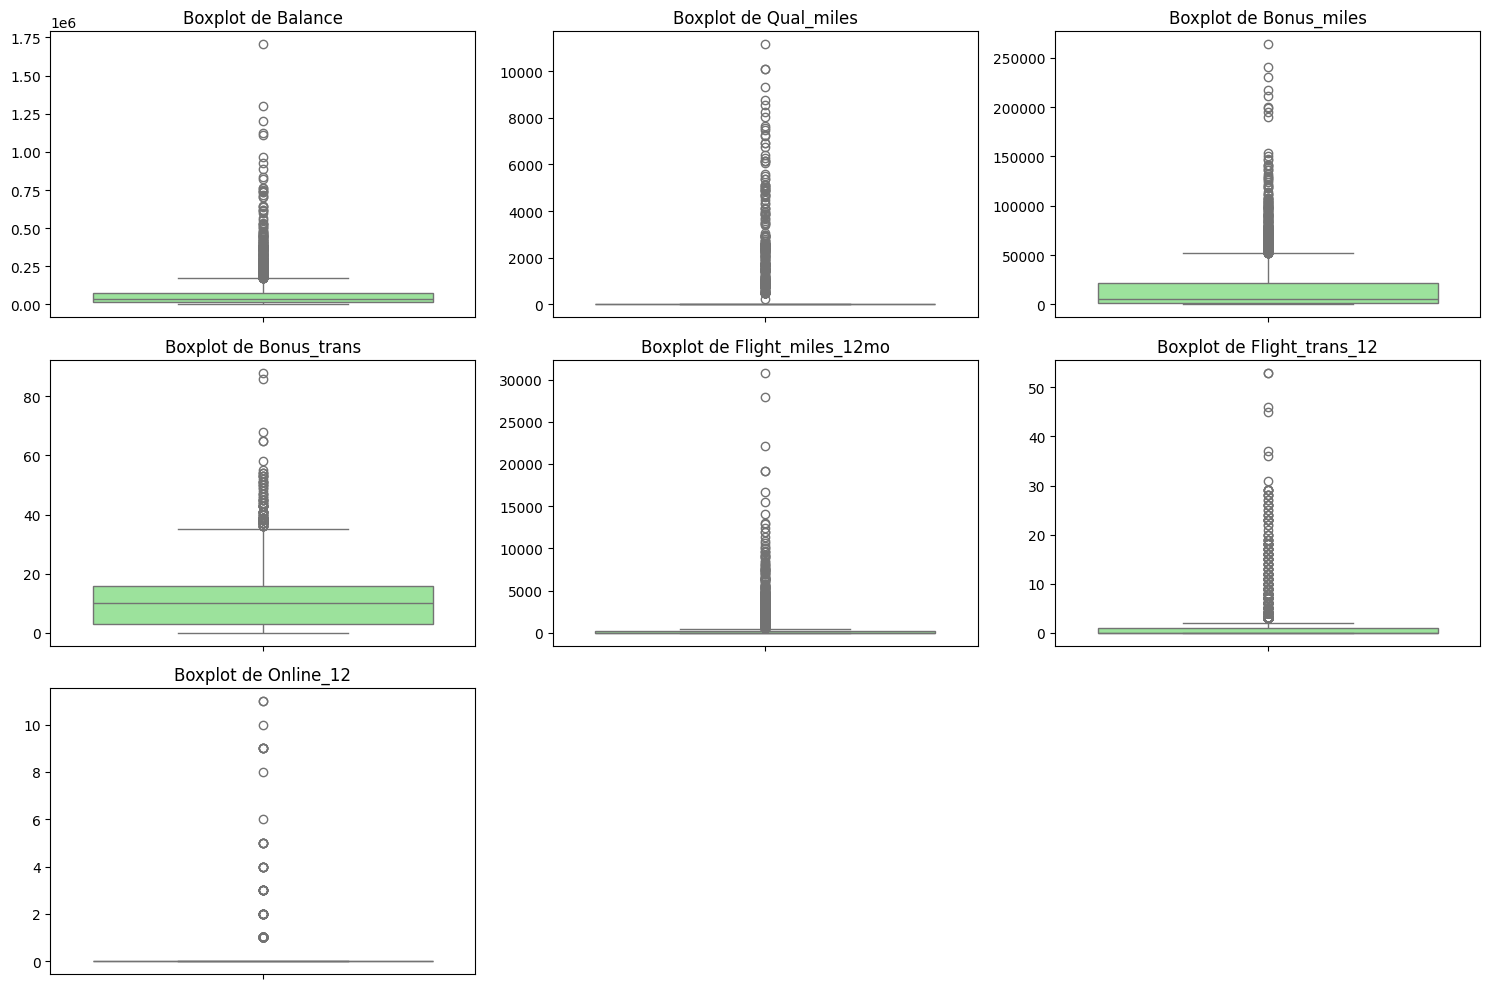

In [ ]:
# 3. Diagramas de Caja (Boxplots) para identificar Outliers (Valores atípicos)
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'Boxplot de {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

#### **Hallazgos del grafico de Bosxplot**
1. Balance
   * Caja muy pequeña cerca de 0
   * Muchísimos outliers hacia arriba
2. Bonus_miles
   * Patrón similar a Balance
   * Outliers muy altos
3. Flight_miles_12mo
   * Caja comprimida
   * Outliers enormes (hasta 30k+)
4. Bonus_trans
   * Más distribuida (mejor que otras) pero aún con outliers
5. Flight_trans_12
   * La mayoría en valores bajos (0–2)
   * Algunos outliers hasta 50+
6. Online_12
   * Ultra concentrado en 0
   * Algunos pocos valores altos


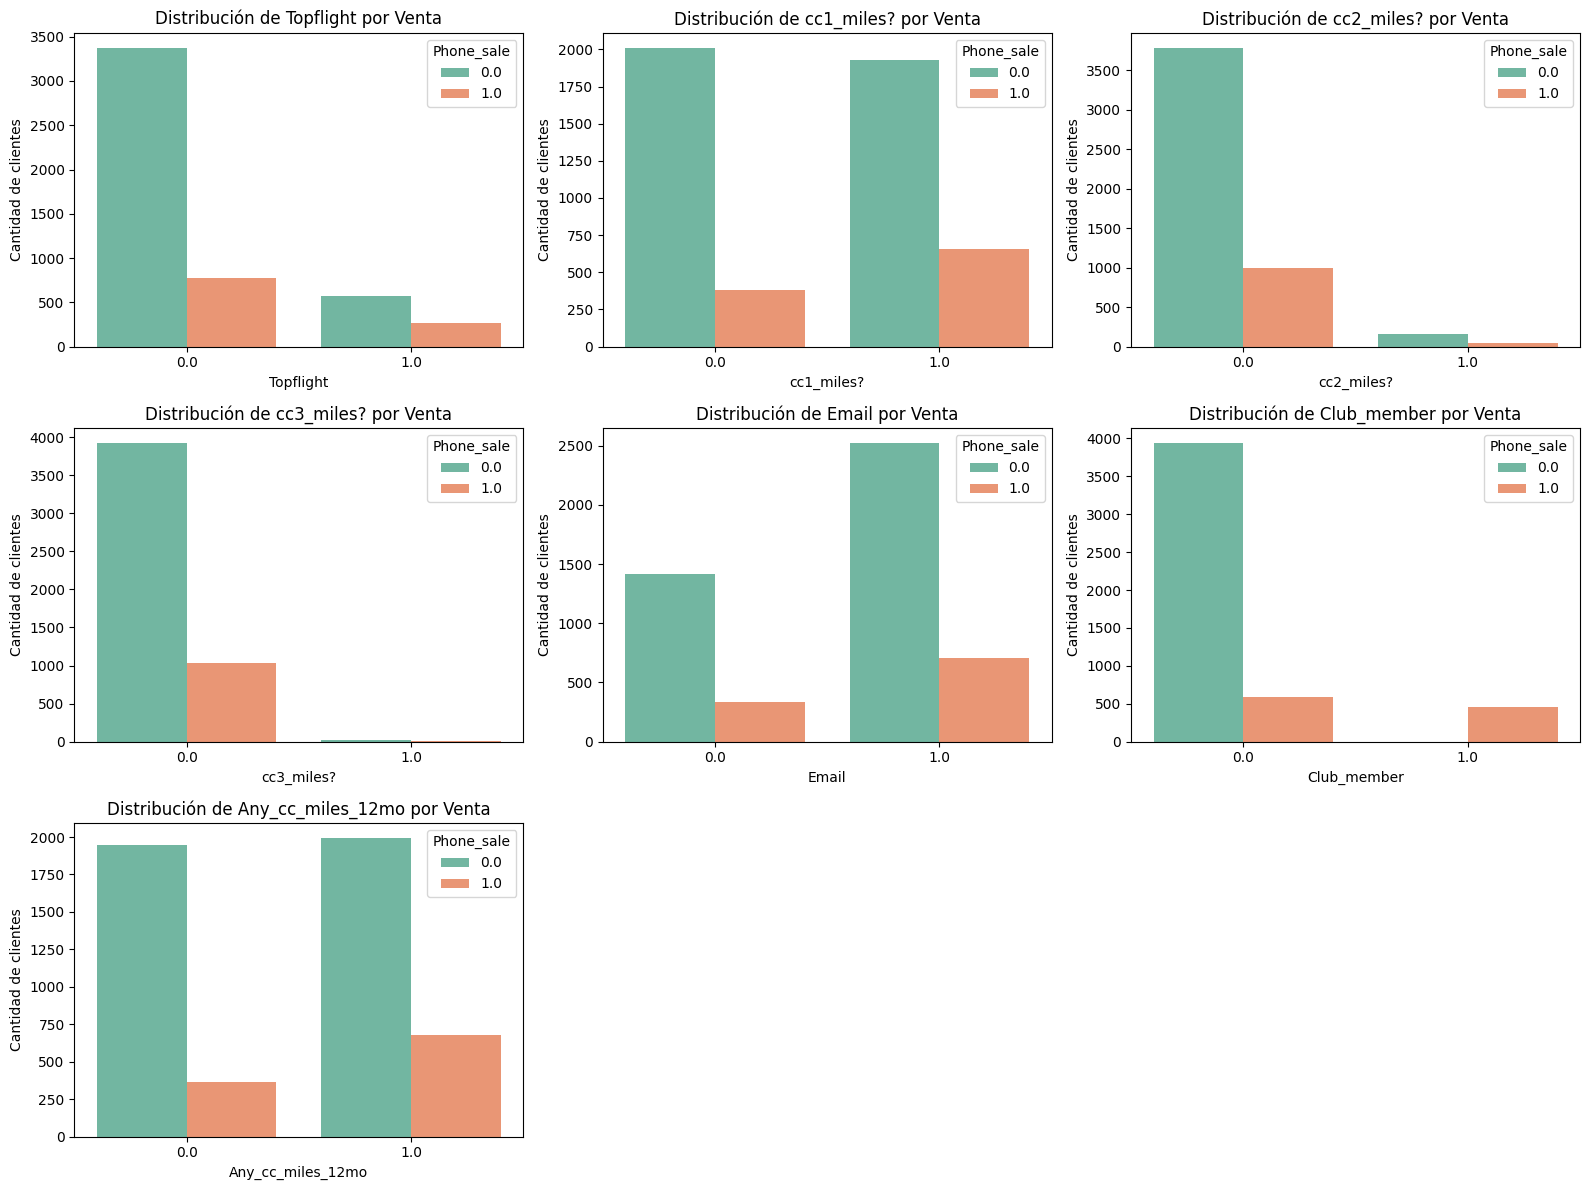

In [ ]:
# Lista de columnas categóricas (
cat_cols = ['Topflight', 'cc1_miles?', 'cc2_miles?', 'cc3_miles?',
            'Email', 'Club_member', 'Any_cc_miles_12mo']

# 1. Gráficos de barras agrupados por la variable objetivo (Phone_sale)
plt.figure(figsize=(16, 12))
for i, col in enumerate(cat_cols, 1):
    # Verificamos que la columna exista en el dataframe para evitar errores
    if col in df.columns:
        plt.subplot(3, 3, i)
        # hue='Phone_sale' divide las barras entre los que compraron (1) y no compraron (0)
        sns.countplot(data=df, x=col, hue='Phone_sale', palette='Set2')
        plt.title(f'Distribución de {col} por Venta')
        plt.xlabel(col)
        plt.ylabel('Cantidad de clientes')
plt.tight_layout()
plt.show()

#### **Hallazgos del Gráficos de barras agrupados por la variable objetivo**
1. Any_cc_miles_12mo
   * Tienen muchos más casos de compra
   * La barra naranja crece bastante en comparación con los que no usan
2. cc1_miles
   * Los que tienen actividad → más compras
   * Clientes financieramente activos → más propensos a comprar
3. Topflight (estatus élite)
   * Clientes premium responden mejor a campañas
4. Club_member (MUY interesante)
   * Cliente que paga membresía = cliente altamente valioso y convertible
5. Email
   * Canal de contacto importa, pero no es el driver principal
6. cc2_miles y cc3_miles
   * No parecen variables fuertes
   * Poca representatividad

##### **Conclusion**

*  Dataset desbalanceado



In [ ]:

# 2. Análisis numérico: Tasas de conversión por categoría
print("\n--- Tasas de Conversión por Categoría ---")
print("Muestra el % de clientes dentro de cada grupo que compraron el servicio.\n")

for col in cat_cols:
    if col in df.columns:
        # Calcular el promedio de Phone_sale nos da directamente la tasa de conversión
        tasa_conversion = df.groupby(col)['Phone_sale'].mean() * 100
        print(f"Tasa de conversión para {col}:")
        for categoria, porcentaje in tasa_conversion.items():
            print(f"  - Categoría {categoria}: {porcentaje:.2f}% compraron")
        print("-" * 30)


--- Tasas de Conversión por Categoría ---
Muestra el % de clientes dentro de cada grupo que compraron el servicio.

Tasa de conversión para Topflight:
  - Categoría 0.0: 18.64% compraron
  - Categoría 1.0: 32.14% compraron
------------------------------
Tasa de conversión para cc1_miles?:
  - Categoría 0.0: 16.03% compraron
  - Categoría 1.0: 25.41% compraron
------------------------------
Tasa de conversión para cc2_miles?:
  - Categoría 0.0: 20.82% compraron
  - Categoría 1.0: 22.71% compraron
------------------------------
Tasa de conversión para cc3_miles?:
  - Categoría 0.0: 20.81% compraron
  - Categoría 1.0: 40.00% compraron
------------------------------
Tasa de conversión para Email:
  - Categoría 0.0: 19.02% compraron
  - Categoría 1.0: 21.92% compraron
------------------------------
Tasa de conversión para Club_member:
  - Categoría 0.0: 12.92% compraron
  - Categoría 1.0: 100.00% compraron
------------------------------
Tasa de conversión para Any_cc_miles_12mo:
  - Catego

## Seleccion de Variables pre procesamiento y Feature Engineering

Con lo visto anteriormente se procedera a eliminar las variables que no suman o son poco relevantes

In [ ]:
df = df.drop(columns=['cc2_miles?', 'cc3_miles?'])
df.head()

,Topflight,Balance,Qual_miles,cc1_miles?,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Online_12,Email,Club_member,Any_cc_miles_12mo,Phone_sale
0,0.0,28143.0,0.0,0.0,174.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0.0,19244.0,0.0,0.0,215.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,41354.0,0.0,1.0,4123.0,4.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,0.0,14776.0,0.0,0.0,500.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,1.0,97752.0,0.0,1.0,43300.0,26.0,2077.0,4.0,0.0,1.0,0.0,1.0,0.0


Convertimos las variables en binarias las que son cualitativas para trabajarlas mejor

In [ ]:
# Conversión de variables binarias

binary_cols = [
    'Topflight',
    'cc1_miles?',
    'Email',
    'Club_member',
    'Any_cc_miles_12mo',
    'Phone_sale'
]

for col in binary_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').astype('int8')

df.dtypes

,0
Topflight,int8
Balance,float64
Qual_miles,float64
cc1_miles?,int8
Bonus_miles,float64
Bonus_trans,float64
Flight_miles_12mo,float64
Flight_trans_12,float64
Online_12,float64
Email,int8


In [ ]:
# Transformación logarítmica para reducir asimetría

log_cols = [
    'Balance',
    'Qual_miles',
    'Bonus_miles',
    'Flight_miles_12mo'
]

for col in log_cols:
    df[col] = np.log1p(df[col])

df[log_cols].head()

,Balance,Qual_miles,Bonus_miles,Flight_miles_12mo
0,10.245089,0.0,5.164786,0.000000
1,9.865007,0.0,5.375278,0.000000
2,10.629949,0.0,8.324579,0.000000
3,9.600827,0.0,6.216606,0.000000
4,11.490199,0.0,10.675931,7.639161


In [ ]:
# Separar variables predictoras y variable objetivo

X = df.drop(columns=['Phone_sale'])
y = df['Phone_sale']

print(X.shape)
print(y.shape)

(4985, 12)
(4985,)


In [ ]:
# División entrenamiento y prueba

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(3988, 12)
(997, 12)


In [ ]:
# Escalamiento de variables numéricas

numeric_cols = [
    'Balance',
    'Qual_miles',
    'Bonus_miles',
    'Bonus_trans',
    'Flight_miles_12mo',
    'Flight_trans_12',
    'Online_12'
]

scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

X_train.head()

,Topflight,Balance,Qual_miles,cc1_miles?,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Online_12,Email,Club_member,Any_cc_miles_12mo
1752,0.0,0.327124,-0.241539,1.0,0.686121,-0.076112,1.631275,0.218002,-0.105923,1.0,0.0,1.0
4375,0.0,-0.531807,-0.241539,0.0,0.084558,0.132575,-0.626449,-0.347457,-0.105923,1.0,0.0,0.0
4886,0.0,0.024449,3.570854,1.0,0.403044,-0.702175,-0.626449,-0.347457,-0.105923,1.0,0.0,1.0
701,0.0,1.889319,-0.241539,1.0,0.903858,0.758638,-0.626449,-0.347457,-0.105923,1.0,0.0,1.0
1784,0.0,0.317165,-0.241539,1.0,0.428918,0.654294,-0.626449,-0.347457,-0.105923,1.0,0.0,1.0


In [ ]:
# Balanceo de clases con SMOTE

smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("Distribución original:")
print(y_train.value_counts())

print("\nDistribución balanceada:")
print(y_train_balanced.value_counts())


Distribución original:
Phone_sale
0.0    3154
1.0     834
Name: count, dtype: int64

Distribución balanceada:
Phone_sale
1.0    3154
0.0    3154
Name: count, dtype: int64


#### Creacion de variables adicionales

1. Intensidad de vuelo
* Qué tan largos/importantes son los vuelos del cliente.

In [ ]:
df['avg_miles_per_flight'] = (
    df['Flight_miles_12mo'] /
    (df['Flight_trans_12'] + 1)
)

2. Engagement con promociones
* Qué tan rentable o intensa es la participación en promociones.

In [ ]:
df['avg_bonus_per_trans'] = (
    df['Bonus_miles'] /
    (df['Bonus_trans'] + 1)
)

3. Nivel de actividad total
* Engagement general del cliente con la aerolínea.

In [ ]:
df['total_activity'] = (
    df['Flight_trans_12'] +
    df['Bonus_trans'] +
    df['Online_12']
)

4. Cliente premium
* Clientes altamente fidelizados.

In [ ]:
df['premium_customer'] = (
    (df['Topflight'] == 1) &
    (df['Club_member'] == 1)
).astype(int)

5. Ratio de calificación élite
* Qué proporción de las millas realmente ayuda al estatus.

In [ ]:
df['qual_ratio'] = (
    df['Qual_miles'] /
    (df['Balance'] + 1)
)

Evaluamos nuevamente la matriz de correlacion para ver si nos quedamos con todas las variables generadas o descartamos agunas

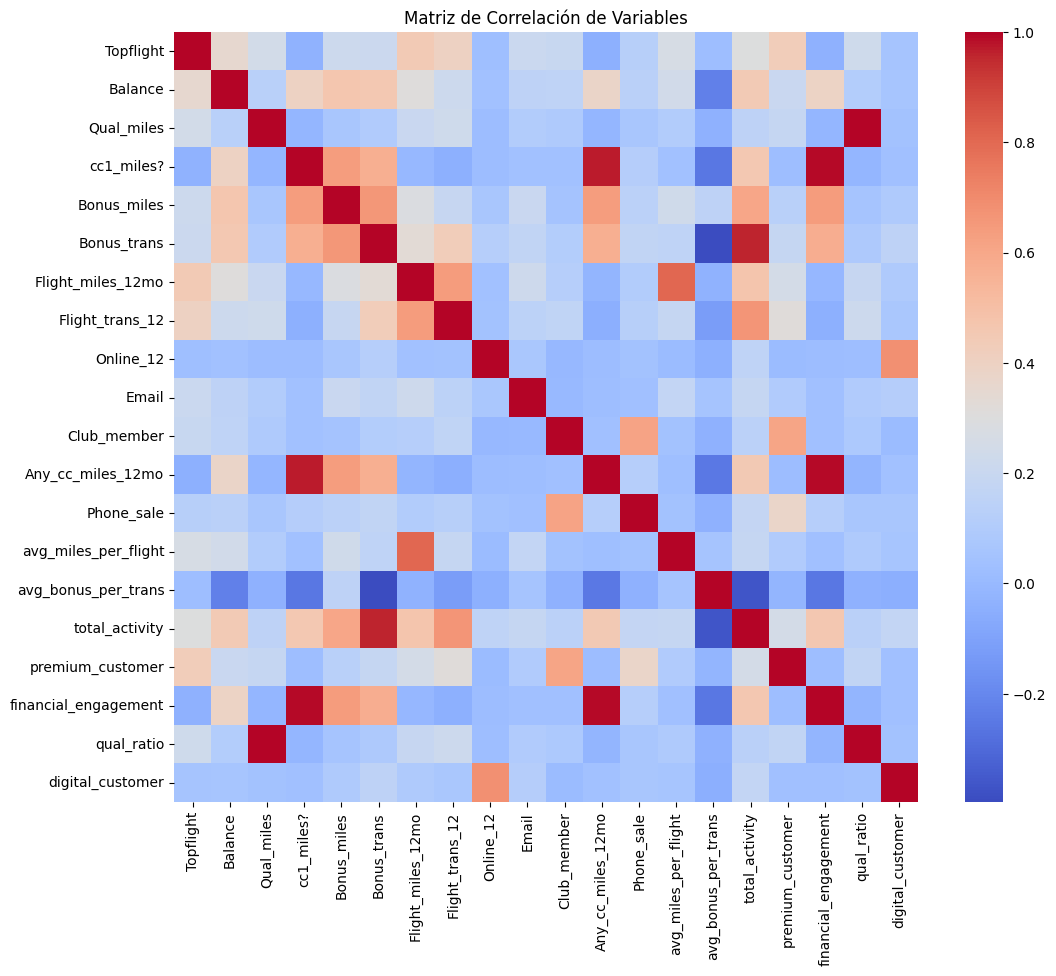

In [ ]:
# Matriz de correlación para ver qué variables se relacionan más con Phone_sale
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables')
plt.show()

Luego de analizar la Matriz de correlacion con las variables nos quedmaos con estas originales:
* Balance
* Qual_miles
* Bonus_miles
* Bonus_trans
* Flight_miles_12mo
* Flight_trans_12
* Online_12
* Topflight
* Email
* Club_member
* Any_cc_miles_12mo
* cc1_miles?

con estas derivadas:
* avg_miles_per_flight
* avg_bonus_per_trans
* total_activity
* premium_customer
* digital_customer

Variables a eliminar:
* financial_engagement

Variable a evaluar
* qual_ratio


In [ ]:
cols_to_drop = [

    'financial_engagement'
]

df = df.drop(columns=cols_to_drop)

print(df.columns)

Index(['Topflight', 'Balance', 'Qual_miles', 'cc1_miles?', 'Bonus_miles',
       'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12', 'Online_12',
       'Email', 'Club_member', 'Any_cc_miles_12mo', 'Phone_sale',
       'avg_miles_per_flight', 'avg_bonus_per_trans', 'total_activity',
       'premium_customer', 'qual_ratio', 'digital_customer'],
      dtype='object')


## Modelamiento

### Logistic Regression

In [ ]:
log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [ ]:
log_model.fit(X_train_balanced, y_train_balanced)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred = log_model.predict(X_test)

In [ ]:
y_prob = log_model.predict_proba(X_test)[:, 1]

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8405215646940822


El modelo clasifica correctamente el 84% de los casos.

In [ ]:
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 0.6622516556291391


Cuando el modelo predice que el cliente va comprar un 66% de las veces tiene razon

In [ ]:
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 0.4807692307692308


El modelo detecta el 48% de los compradores reales.

In [ ]:
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.5571030640668524


EL modelo tiene un desempeño moderado en general

In [ ]:
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.7602064443794482


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.87      0.94      0.90       789
         1.0       0.66      0.48      0.56       208

    accuracy                           0.84       997
   macro avg       0.77      0.71      0.73       997
weighted avg       0.83      0.84      0.83       997



* Macro avg = 0.73 Promedio simple entre clases.
* Weighted avg = 0.83 Promedio ponderado según cantidad de registros.
* Detecta el 94% de no compradores.

#### Conclusion: La regresión logística obtuvo un accuracy de 84%, mostrando un buen desempeño general. Sin embargo, debido al desbalance de clases, el análisis se centró principalmente en la capacidad del modelo para identificar compradores reales. El modelo alcanzó un recall de 48% para la clase positiva, indicando que aún existe margen de mejora en la detección de clientes con probabilidad de compra.”


In [ ]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[738  51]
 [108 100]]


#### Matriz de confusion

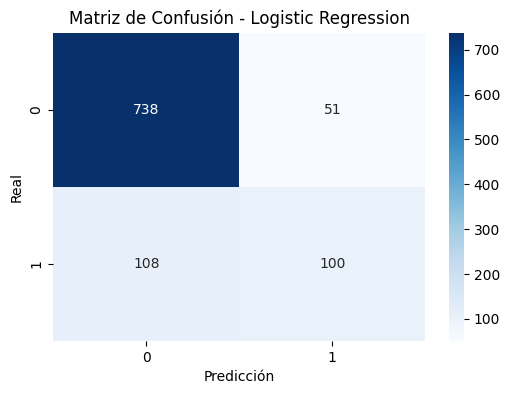

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Logistic Regression")

plt.show()

La matriz de confusión evidencia que el modelo presenta un desempeño sólido identificando clientes que no realizarán la compra. Sin embargo, aún existen limitaciones en la detección de compradores reales, reflejadas en la cantidad de falsos negativos. Esto sugiere la necesidad de optimizar el recall mediante ajuste de umbral o modelos más complejos.

#### Importancia de variables

In [ ]:
feature_importance = pd.DataFrame({
    'Variable': X_train_balanced.columns,
    'Coeficiente': log_model.coef_[0]
})

feature_importance = feature_importance.sort_values(
    by='Coeficiente',
    ascending=False
)

feature_importance

,Variable,Coeficiente
10,Club_member,7.027047
4,Bonus_miles,0.605260
11,Any_cc_miles_12mo,0.281926
5,Bonus_trans,0.148251
9,Email,0.090796
8,Online_12,0.049032
7,Flight_trans_12,0.031309
6,Flight_miles_12mo,-0.023393
2,Qual_miles,-0.034778
3,cc1_miles?,-0.131865


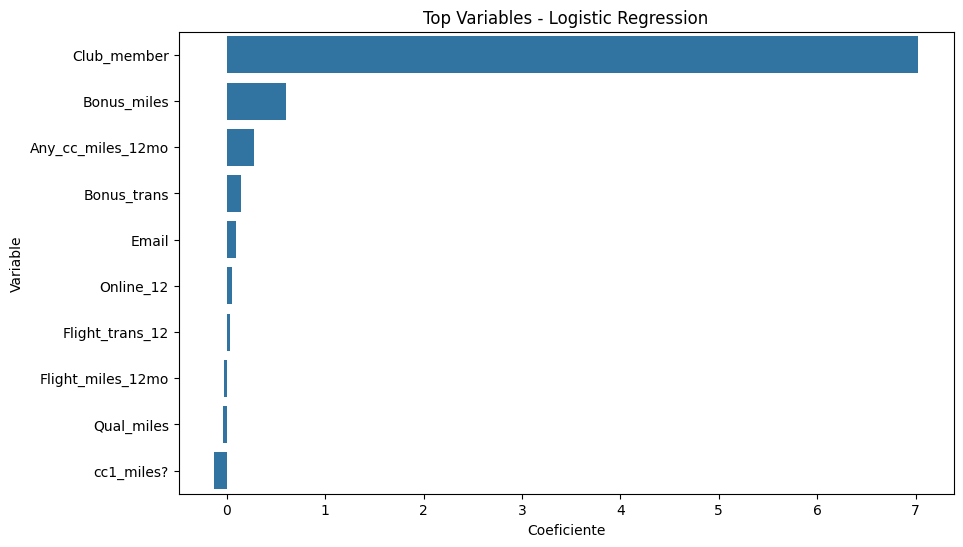

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Coeficiente',
    y='Variable'
)

plt.title("Top Variables - Logistic Regression")

plt.show()

* Club_member = 7.02
  * La membresía al club es el principal predictor de compra, indicando que los clientes con mayor nivel de fidelización presentan una propensión significativamente más alta a responder a campañas comerciales.
* Bonus_miles = 0.60
  * Clientes que acumulan millas bonus, tienen mayor probabilidad de compra
* Any_cc_miles_12mo = 0.28
  * Actividad financiera relacionada con tarjetas: aumenta probabilidad de compra
* Bonus_trans = 0.14
  * Más transacciones bonus: ligeramente más probabilidad de compra
* Email = 0.09
  * Tener email registrado, ayuda un poco
* Online_12, Flight_trans_12
  * Aportan poco al modelo.
* Topflight = -0.38
  * Clientes élite parecen MENOS propensos a comprar. Posible respuesta a este comportamiento extraño Ya tienen beneficios premium :No necesitan comprar adicionales.
* Balance = -0.19
  * Tener muchas millas acumuladas, reduce ligeramente la probabilidad de compra. Posible explicacion: ya tienen suficientes beneficios
* cc1_miles? = -0.13
  * Any_cc_miles_12mo salió positiva lo que podria indicar redundancia parcial
* Qual_miles
  * Muy leve negativo. No parece importante realmente.

#### La variable con mayor influencia positiva en la probabilidad de compra fue la membresía al club, seguida por la acumulación de millas bonus y la actividad relacionada con tarjetas de crédito. Por otro lado, variables asociadas al estatus élite y altos balances de millas mostraron una relación negativa con la conversión, sugiriendo que los clientes altamente consolidados podrían tener menor necesidad de adquirir nuevos servicios.

Con esta conclusion se procedara a ejcutar un Logistica con las variables reducidas

### Logistic Regression Reducido

In [ ]:
selected_features = [
    'Club_member',
    'Bonus_miles',
    'Any_cc_miles_12mo',
    'Bonus_trans',
    'Email',
    'Topflight',
    'Balance',
    'cc1_miles?'
]

In [ ]:
# Crear nuevos datasets reducidos
X_train_reduced = X_train_balanced[selected_features]
X_test_reduced = X_test[selected_features]

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model_reduced = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [ ]:
log_model_reduced.fit(
    X_train_reduced,
    y_train_balanced
)


LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred_reduced = log_model_reduced.predict(X_test_reduced)

y_prob_reduced = log_model_reduced.predict_proba(
    X_test_reduced
)[:, 1]

In [ ]:
print(classification_report(
    y_test,
    y_pred_reduced
))

              precision    recall  f1-score   support

         0.0       0.87      0.93      0.90       789
         1.0       0.64      0.47      0.54       208

    accuracy                           0.84       997
   macro avg       0.76      0.70      0.72       997
weighted avg       0.82      0.84      0.83       997



In [ ]:
cm_reduced = confusion_matrix(
    y_test,
    y_pred_reduced
)
print(cm_reduced)


[[735  54]
 [110  98]]


La reducción de variables no generó mejoras en el desempeño del modelo. Por el contrario, se observó una ligera disminución en métricas clave como Recall y F1-score para la clase positiva. Esto sugiere que las variables eliminadas aportaban información complementaria al modelo, incluso cuando sus coeficientes individuales parecían bajos

### Random Forest

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)


In [ ]:
rf_model.fit(
    X_train_balanced,
    y_train_balanced
)


RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=5, min_samples_split=10,
                       n_estimators=200, n_jobs=-1, random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

Accuracy: 0.8324974924774323


In [ ]:
print("Precision:", precision_score(y_test, y_pred_rf))

Precision: 0.6257668711656442


In [ ]:
print("Recall:", recall_score(y_test, y_pred_rf))

Recall: 0.49038461538461536


In [ ]:
print("F1 Score:", f1_score(y_test, y_pred_rf))

F1 Score: 0.5498652291105122


In [ ]:
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

ROC-AUC: 0.771144096714439


In [ ]:
print(classification_report(
    y_test,
    y_pred_rf
))


              precision    recall  f1-score   support

         0.0       0.87      0.92      0.90       789
         1.0       0.63      0.49      0.55       208

    accuracy                           0.83       997
   macro avg       0.75      0.71      0.72       997
weighted avg       0.82      0.83      0.82       997



Random Forest NO mejoró significativamente frente a Logistic Regression.
* Recall mejoró ligeramente 0.48 → 0.49
* Precision bajó 0.66 → 0.63


#### Matriz de confusion

In [ ]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

print(cm_rf)


[[728  61]
 [106 102]]


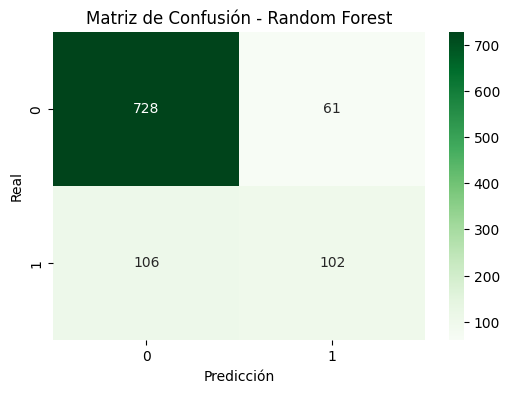

In [ ]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.xlabel("Predicción")
plt.ylabel("Real")

plt.title("Matriz de Confusión - Random Forest")

plt.show()

* Si quieres:detectar más compradores Random Forest gana ligeramente.
* Si quieres: menos campañas innecesarias Logistic Regression gana.

El modelo Random Forest mostró un comportamiento similar al de la regresión logística. Si bien logró incrementar ligeramente el recall de la clase positiva, este aumento vino acompañado de un mayor número de falsos positivos. En general, ambos modelos presentan desempeños comparables, sugiriendo que la información contenida en las variables actuales tiene una capacidad predictiva moderad

#### Importancia de variables

In [ ]:

feature_importance_rf = pd.DataFrame({
    'Variable': X_train_balanced.columns,
    'Importancia': rf_model.feature_importances_
})

feature_importance_rf = feature_importance_rf.sort_values(
    by='Importancia',
    ascending=False
)

print("\n===== FEATURE IMPORTANCE =====")

print(feature_importance_rf)


===== FEATURE IMPORTANCE =====
             Variable  Importancia
10        Club_member     0.561052
5         Bonus_trans     0.123776
4         Bonus_miles     0.087927
1             Balance     0.070688
7     Flight_trans_12     0.041017
6   Flight_miles_12mo     0.032239
0           Topflight     0.023634
11  Any_cc_miles_12mo     0.017022
3          cc1_miles?     0.015197
9               Email     0.015175
2          Qual_miles     0.008042
8           Online_12     0.004231


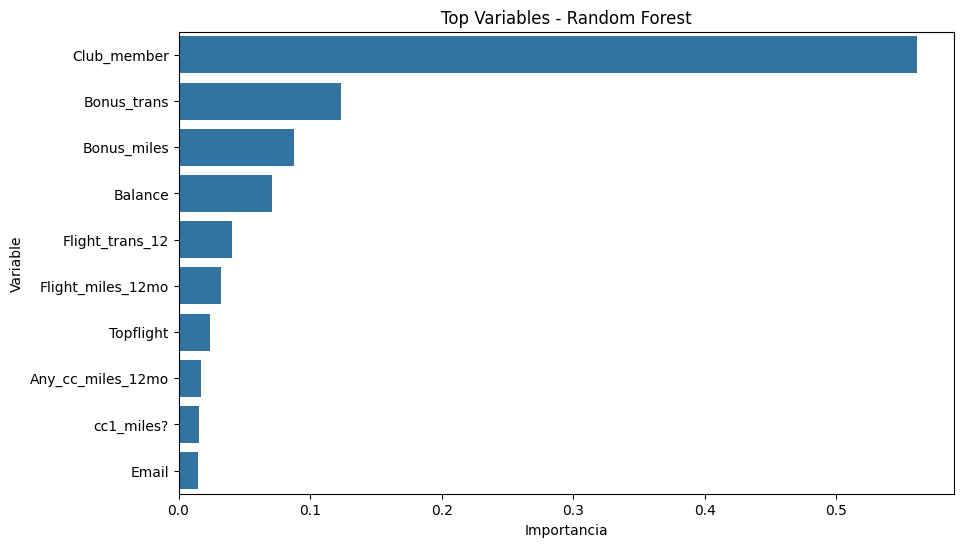

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance_rf.head(10),
    x='Importancia',
    y='Variable'
)

plt.title("Top Variables - Random Forest")

plt.show()


* Club_member = 0.56
  * Más de la mitad de la capacidad predictiva viene de esta variable.
* Bonus_trans = 0.12
  * En Random Forest: pesa más que Bonus_miles.
* Bonus_miles = 0.087
  * Clientes que acumulan millas bonus: responden mejor a campañas
* Balance = 0.07
  * En RF: sí aporta
* Flight_trans_12 y Flight_miles_12mo
  * aportan algo.
* Qual_miles y Online_12
  * prácticamente no aportan.


El análisis de importancia de variables mediante Random Forest identificó a la membresía al club como el principal predictor de compra, representando más del 50% de la capacidad explicativa del modelo. Asimismo, las variables relacionadas con promociones y acumulación de millas bonus mostraron una relevancia considerable, mientras que variables asociadas al estatus élite y actividad de vuelo tuvieron una contribución significativamente menor

### Random Forest Reducido

In [ ]:
cols_to_drop = [
    'Online_12',
    'Qual_miles'
]

# Crear nuevo dataframe sin variables débiles
X_train_rf_reduced = X_train_balanced.drop(
    columns=cols_to_drop
)

X_test_rf_reduced = X_test.drop(
    columns=cols_to_drop
)


In [ ]:
print(X_train_rf_reduced.columns)

Index(['Topflight', 'Balance', 'cc1_miles?', 'Bonus_miles', 'Bonus_trans',
       'Flight_miles_12mo', 'Flight_trans_12', 'Email', 'Club_member',
       'Any_cc_miles_12mo'],
      dtype='object')


In [ ]:
rf_model_reduced = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

In [ ]:
rf_model_reduced.fit(
    X_train_rf_reduced,
    y_train_balanced
)


RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=5, min_samples_split=10,
                       n_estimators=200, n_jobs=-1, random_state=42)

In [ ]:
y_pred_rf_reduced = rf_model_reduced.predict(
    X_test_rf_reduced
)

y_prob_rf_reduced = rf_model_reduced.predict_proba(
    X_test_rf_reduced
)[:, 1]


In [ ]:
print("\n===== CLASSIFICATION REPORT =====")

print(classification_report(
    y_test,
    y_pred_rf_reduced
))


===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

         0.0       0.87      0.92      0.89       789
         1.0       0.61      0.49      0.54       208

    accuracy                           0.83       997
   macro avg       0.74      0.70      0.72       997
weighted avg       0.82      0.83      0.82       997



In [ ]:
cm_rf_reduced = confusion_matrix(
    y_test,
    y_pred_rf_reduced
)

print("\n===== MATRIZ DE CONFUSIÓN =====")

print(cm_rf_reduced)


===== MATRIZ DE CONFUSIÓN =====
[[725  64]
 [107 101]]


La reducción de variables en el modelo Random Forest produjo una disminución en el desempeño general, particularmente en precision y F1-score. Esto evidencia que incluso variables con baja importancia individual aportaban información complementaria al proceso de clasificación, contribuyendo a una mejor estabilidad del modelo.

El problema principal de tu modelo NO es accuracy es el recall bajo para compradores por lo que si bajamos el threshold podemos obtener mejores resultados haciendo que se cambio lo que esta por defecto de 0.5 a [0.3, 0.4, 0.45, 0.5, 0.55]

### Random Forest threshold

In [ ]:
thresholds = [0.3, 0.4, 0.45, 0.5, 0.55]

for t in thresholds:

    y_pred_t = (y_prob >= t).astype(int)

    print(f"\n===== Threshold: {t} =====")

    print(classification_report(
        y_test,
        y_pred_t
    ))


===== Threshold: 0.3 =====
              precision    recall  f1-score   support

         0.0       0.92      0.35      0.51       789
         1.0       0.26      0.88      0.41       208

    accuracy                           0.46       997
   macro avg       0.59      0.62      0.46       997
weighted avg       0.78      0.46      0.49       997


===== Threshold: 0.4 =====
              precision    recall  f1-score   support

         0.0       0.89      0.63      0.74       789
         1.0       0.33      0.70      0.45       208

    accuracy                           0.65       997
   macro avg       0.61      0.66      0.59       997
weighted avg       0.77      0.65      0.68       997


===== Threshold: 0.45 =====
              precision    recall  f1-score   support

         0.0       0.87      0.81      0.84       789
         1.0       0.43      0.55      0.48       208

    accuracy                           0.76       997
   macro avg       0.65      0.68      0.66

* Threshold = 0.3
  * Precision	0.26
  * Recall	0.88
* Threshold = 0.4
  * Precision	0.33
  * Recall	0.70
* Threshold = 0.45
  * Precision	0.43
  * Recall	0.55
* Threshold = 0.55
  * Precision	0.87
  * Recall	0.44


El ajuste del threshold permitió modificar el balance entre precision y recall según las necesidades del negocio. Umbrales más bajos incrementaron significativamente la capacidad de detección de compradores reales, aunque a costa de un mayor número de falsos positivos. En particular, un threshold de 0.45 mostró un equilibrio más adecuado entre capacidad predictiva y eficiencia operativa

### Xgboost

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)


In [ ]:
xgb_model.fit(
    X_train_balanced,
    y_train_balanced
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgb_model.predict(X_test)

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

Accuracy: 0.8284854563691073


In [ ]:
print("Precision:", precision_score(y_test, y_pred_xgb))

Precision: 0.6163522012578616


In [ ]:
print("Recall:", recall_score(y_test, y_pred_xgb))

Recall: 0.47115384615384615


In [ ]:
print("F1 Score:", f1_score(y_test, y_pred_xgb))

F1 Score: 0.5340599455040872


In [ ]:
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

ROC-AUC: 0.7620771180657112


In [ ]:
print("\n===== CLASSIFICATION REPORT =====")

print(classification_report(
    y_test,
    y_pred_xgb
))



===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

         0.0       0.87      0.92      0.89       789
         1.0       0.62      0.47      0.53       208

    accuracy                           0.83       997
   macro avg       0.74      0.70      0.71       997
weighted avg       0.82      0.83      0.82       997



#### Matriz de confusion

In [ ]:
cm_xgb = confusion_matrix(
    y_test,
    y_pred_xgb
)

print("\n===== MATRIZ DE CONFUSIÓN =====")

print(cm_xgb)


===== MATRIZ DE CONFUSIÓN =====
[[728  61]
 [110  98]]


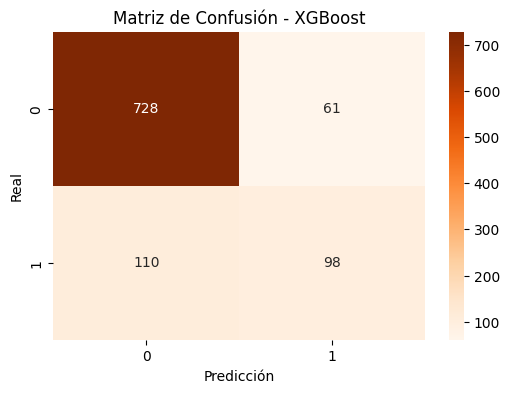

In [ ]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.xlabel("Predicción")
plt.ylabel("Real")

plt.title("Matriz de Confusión - XGBoost")

plt.show()

A pesar de probar modelos más complejos como Random Forest y XGBoost, la regresión logística presentó el mejor equilibrio general entre precisión, recall y estabilidad. Esto sugiere que las relaciones presentes en los datos poseen un comportamiento predominantemente lineal y que modelos más sofisticados no aportaron mejoras significativas en capacidad predictiva.

#### Importancia de Variables

In [ ]:
feature_importance_xgb = pd.DataFrame({
    'Variable': X_train_balanced.columns,
    'Importancia': xgb_model.feature_importances_
})

feature_importance_xgb = feature_importance_xgb.sort_values(
    by='Importancia',
    ascending=False
)

print("\n===== FEATURE IMPORTANCE =====")

print(feature_importance_xgb)


===== FEATURE IMPORTANCE =====
             Variable  Importancia
10        Club_member     0.652169
11  Any_cc_miles_12mo     0.059601
5         Bonus_trans     0.049151
0           Topflight     0.043919
3          cc1_miles?     0.034155
7     Flight_trans_12     0.031015
4         Bonus_miles     0.030624
9               Email     0.029836
1             Balance     0.020186
6   Flight_miles_12mo     0.019694
2          Qual_miles     0.015309
8           Online_12     0.014340


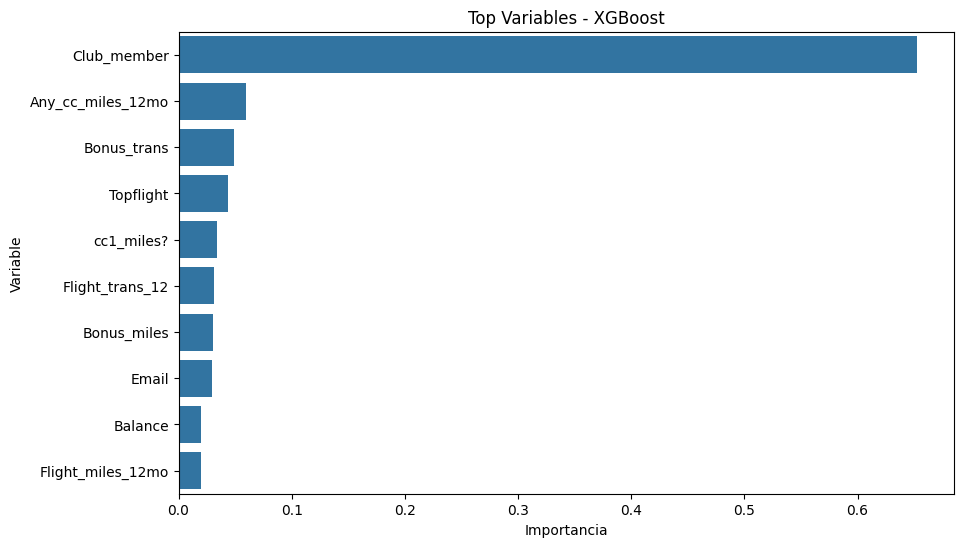

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance_xgb.head(10),
    x='Importancia',
    y='Variable'
)

plt.title("Top Variables - XGBoost")

plt.show()

La variable Club_member concentró más del 65% de la importancia total en el modelo XGBoost, consolidándose como el principal predictor de compra. Este comportamiento fue consistente en todos los modelos evaluados, sugiriendo que el nivel de fidelización del cliente constituye el factor más determinante en la probabilidad de conversión.

### Regresion Logistica con threshold = 0.45

In [ ]:
y_prob = log_model.predict_proba(X_test)[:, 1]

In [ ]:
threshold = 0.45

# Convertir probabilidades a clases
y_pred_threshold = (
    y_prob >= threshold
).astype(int)


In [ ]:
print("\n===== CLASSIFICATION REPORT =====")

print(classification_report(
    y_test,
    y_pred_threshold
))


===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

         0.0       0.87      0.81      0.84       789
         1.0       0.43      0.55      0.48       208

    accuracy                           0.76       997
   macro avg       0.65      0.68      0.66       997
weighted avg       0.78      0.76      0.77       997



In [ ]:

cm_threshold = confusion_matrix(
    y_test,
    y_pred_threshold
)

print("\n===== MATRIZ DE CONFUSIÓN =====")

print(cm_threshold)


===== MATRIZ DE CONFUSIÓN =====
[[639 150]
 [ 94 114]]


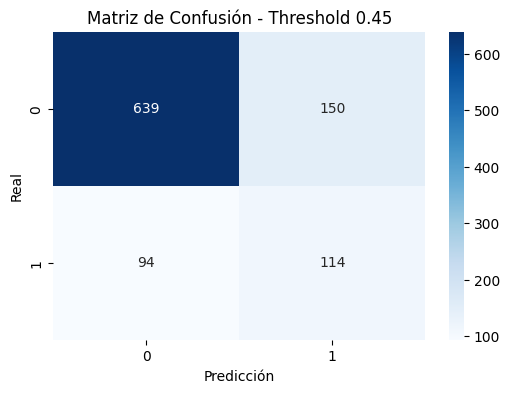

In [ ]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm_threshold,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicción")
plt.ylabel("Real")

plt.title(f"Matriz de Confusión - Threshold {threshold}")

plt.show()

Con este ultimo cambio el modelo es mas agresivo Antes: Solo clasificaba compradores cuando estaba muy seguro. Ahora, Prefiere: Mejor contactar más clientes y no perder compradores. Es bueno o malo ?
* Campañas baratas (email marketing)
  * Esto puede ser EXCELENTE.enviar emails cuesta poco, vale la pena aumentar Recall
* Campañas caras (call center, ventas humanas)
  * Puede ser malo. 150 falsos positivos es costoso


El ajuste del threshold permitió incrementar la capacidad del modelo para identificar compradores reales, elevando el recall de 48% a 55%. Sin embargo, esta mejora vino acompañada de un aumento considerable en falsos positivos, evidenciando el tradeoff natural entre sensibilidad y precisión en modelos de clasificación.

## Conclusion Final

Durante el desarrollo del proyecto se evaluaron distintos modelos de clasificación con el objetivo de predecir la probabilidad de compra de clientes (Phone_sale). Para ello, se aplicaron técnicas de análisis exploratorio, limpieza de datos, transformación de variables, balanceo de clases y modelamiento predictivo.

Se compararon modelos de:

* Regresión Logística
* Random Forest
* XGBoost

Los resultados mostraron que la Regresión Logística obtuvo el mejor desempeño general, superando incluso a modelos más complejos como Random Forest y XGBoost. Esto sugiere que las relaciones presentes en los datos poseen un comportamiento predominantemente lineal y que modelos más sofisticados no aportaron mejoras significativas en capacidad predictiva.

### Modelo Finalista 1: Logistic Regression (Threshold = 0.5)

Fortalezas principales
  * El mejor equilibrio general entre precisión y estabilidad
  * Mayor precisión al identificar compradores
  * Menor cantidad de falsos positivos
  * Mejor F1-score entre todos los modelos evaluados


 Resultados destacados
  * Accuracy: 84%
  * Precision clase positiva: 66%
  * Recall clase positiva: 48%
  * F1-score clase positiva: 56%


¿En qué es bueno este modelo?
* El costo de contactar clientes incorrectos es alto
* se busca eficiencia en campañas comerciales
* se prioriza precisión sobre volumen

Por ejemplo:

* campañas telefónicas
* ventas asistidas
* estrategias comerciales con presupuesto limitado


El modelo logra identificar compradores con una tasa de error relativamente baja, permitiendo focalizar campañas en clientes con mayor probabilidad de conversión y reduciendo esfuerzos innecesarios.

### Modelo Finalista 2: Logistic Regression (Threshold = 0.45)

Fortalezas principales

* aumentO la sensibilidad del modelo
* detectO una mayor cantidad de compradores reales
* redujo falsos negativos


Resultados destacados
* Accuracy: 76%
* Precision clase positiva: 43%
* Recall clase positiva: 55%

¿En qué es bueno este modelo?
* Cuando el objetivo principal es captar la mayor cantidad posible de compradores
* Cuando perder oportunidades comerciales es más costoso que generar falsos positivos
* Cuando el costo de las campañas es bajo

Por ejemplo:
* email marketing
* campañas masivas digitales
* promociones automatizadas

Al reducir el threshold, el modelo se vuelve más agresivo al clasificar clientes como compradores potenciales. Esto incrementa la capacidad de detección de oportunidades comerciales, aunque también aumenta el número de clientes contactados incorrectamente.


El proyecto permitió construir modelos predictivos funcionales y comparables, identificando que la Regresión Logística ofrece el mejor equilibrio entre interpretabilidad, estabilidad y desempeño predictivo para este caso de negocio.

Además, se comprobó que el ajuste del threshold puede adaptar el modelo según la estrategia comercial deseada:

mayor precisión y eficiencia operativa
o
mayor capacidad de captación de clientes potenciales